In [1]:
from sacrebleu.metrics import BLEU
import re
import itertools
from nltk.tokenize import sent_tokenize
import os
import json
from scipy import stats
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../..')
from style_setup import set_thesis_style
set_thesis_style()


# Analysis functions

In [2]:
# Ensure NLTK's sentence tokenizer is downloaded
try:
    import nltk
    nltk.data.find('tokenizers/punkt')
except (ImportError, nltk.downloader.DownloadError):
    nltk.download('punkt')

def remove_markdown(text):
    """Removes markdown formatting (#, *) from text."""
    text = re.sub(r'#+', '', text)
    text = re.sub(r'\*\*', '', text)
    text = re.sub(r'\*', '', text)
    return text.strip()

def is_valid_sentence(sentence):
    """
    Checks if a sentence is valid for analysis.
    - Not empty
    - Not just a numbered list marker (e.g., "1.", "2.")
    - Longer than 3 characters after cleaning
    """
    sentence = sentence.strip()
    if not sentence:
        return False
    
    cleaned = remove_markdown(sentence)
    
    # Check for numbered list markers like "1." or "### 8."
    if cleaned.replace('.', '').isdigit():
        return False
    
    # Check if sentence is too short
    if len(cleaned) < 3:
        return False
        
    # Check for patterns like "1." with no further content
    if cleaned.endswith('.') and cleaned[:-1].isdigit():
        return False
    
    return True

def calculate_self_bleu(sentences, n_gram=4):
    """
    Calculates the Self-BLEU score for a list of sentences.
    
    Returns 100.0 if there are fewer than two sentences, as there is no diversity to measure.
    """
    if len(sentences) < 2:
        return 100.0  # Assign max score (min diversity) if not enough sentences
    
    bleu = BLEU(max_ngram_order=n_gram, effective_order=True)
    scores = []
    
    for i in range(len(sentences)):
        hypothesis = [sentences[i]]
        references = [[s] for j, s in enumerate(sentences) if i != j]
        score = bleu.corpus_score(hypothesis, references)
        scores.append(score.score)
        
    return sum(scores) / len(scores)

def load_and_clean_responses(file_path):
    """Loads and preprocesses responses from a JSONL file."""
    responses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            if "response_model" in data and data["response_model"]:
                responses.append(data["response_model"])

    clean_responses = []
    for resp in responses:
        sentences = sent_tokenize(resp)
        valid_sentences = [s for s in sentences if is_valid_sentence(s)]
        clean_sentences = [remove_markdown(s) for s in valid_sentences]
        # Only include sentences with at least 4 words
        final_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
        if final_sentences:
            clean_responses.append(final_sentences)
            
    return clean_responses


def calculate_self_bleu_scores(
    data_paths,
    output_dir_template,
    mode,
    sample_number,
    save=False,
    n_gram=4,
    seed=42
):
    """
    Calculates Self-BLEU scores for a list of sentences.
    
    Returns 100.0 if there are fewer than two sentences, as there is no diversity to measure.
    """
    if mode not in ['individual', 'aggregated']:
        raise ValueError("Mode must be 'individual' or 'aggregated'.")

    # The main seed is now used as a base, and we will derive a specific seed for each file
    output_base_dir = output_dir_template.format(mode=mode, n_gram=n_gram)
    
    print(f"--- Running Self-BLEU Calculation (Mode: {mode}, N-gram: {n_gram}) ---")

    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        # The output directory is now the base directory, without the 'size' subfolder.
        output_dir = output_base_dir
        if save:
            os.makedirs(output_dir, exist_ok=True)

        # Enumerate over the file_paths to get a stable index for each file
        for i, file_path in enumerate(tqdm(file_paths, desc=f"  Files for {size}")):
            # Set a deterministic seed for each file to ensure reproducible sampling
            # The seed is based on the main seed and the file's position in the list
            np.random.seed(seed + i)

            model_name = os.path.splitext(os.path.basename(file_path))[0]
            
            clean_responses = load_and_clean_responses(file_path)
            
            # For aggregated mode, filter to responses with at least 2 sentences
            # to maintain consistency with the individual calculation pool.
            if mode == 'aggregated':
                eligible_responses = [r for r in clean_responses if len(r) >= 2]
            else:
                eligible_responses = clean_responses
                
            if len(eligible_responses) < sample_number:
                print(f"\nWarning: Only {len(eligible_responses)} eligible responses found for {model_name} (requested {sample_number}). Using all available.")
                response_samples = eligible_responses
            else:
                indices = np.random.choice(len(eligible_responses), size=sample_number, replace=False)
                response_samples = [eligible_responses[i] for i in indices]

            # --- Score Calculation ---
            if mode == 'individual':
                scores = [calculate_self_bleu(sample, n_gram) for sample in response_samples if len(sample) >= 2]
                if not scores:
                    print(f"Warning: No valid samples to calculate individual scores for {model_name}.")
                    continue
                avg_self_bleu = np.mean(scores)
                lex_div_scores = [100 - s for s in scores]
                avg_lex_div = np.mean(lex_div_scores)
            else: # aggregated mode
                all_sentences = [s for resp in response_samples for s in resp]
                avg_self_bleu = calculate_self_bleu(all_sentences, n_gram)
                avg_lex_div = 100 - avg_self_bleu

            # --- Result Saving ---
            if save:
                output_file = os.path.join(output_dir, f"{model_name}_self_bleu.jsonl")
                entry = {
                    "source": model_name,
                    "size": size,
                    f"average_self_bleu_{n_gram}": avg_self_bleu,
                    "average_lexical_diversity": avg_lex_div,
                }
                if mode == 'individual':
                    entry["lexical_diversity_scores"] = lex_div_scores
                
                with open(output_file, 'w') as f:
                    f.write(json.dumps(entry) + '\n')
    
    print("--- Calculation complete. ---")

# Run code

## Small models

### Calculate scores


In [15]:
# --- Configuration ---
N_GRAM = 3
SAMPLE_NUMBER = 1500
SAVE_RESULTS = True
BASE_DATA_DIR = "/Users/maxschaffelder/Desktop/Thesis/data/exp_1"
MODEL_SIZE = "small"

# Using new, corrected file paths
model_paths = {
    "Small": [
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_lora_llama_8b_single.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_lora_llama_8b_multi.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_lora_llama_8b_human.jsonl",
        "/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_test_Llama.jsonl"
    ],
    # Add paths for "Medium" and "Large" models here if needed
}

output_dir_template = f"{BASE_DATA_DIR}/{MODEL_SIZE}/lex_div/self_bleu_{{mode}}_{{n_gram}}"

# --- Run Calculations ---
# Calculate scores for individual responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='individual',
    sample_number=SAMPLE_NUMBER,
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

# Calculate scores for aggregated responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='aggregated',
    sample_number=100,  # Using 100 for aggregated as in original code
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

--- Running Self-BLEU Calculation (Mode: individual, N-gram: 3) ---
Processing Small models...


  Files for Small:  25%|██▌       | 1/4 [00:06<00:20,  6.88s/it]

  Files for Small:  50%|█████     | 2/4 [00:13<00:13,  6.82s/it]

  Files for Small:  75%|███████▌  | 3/4 [00:16<00:05,  5.22s/it]

  Files for Small: 100%|██████████| 4/4 [00:23<00:00,  5.86s/it]


--- Calculation complete. ---
--- Running Self-BLEU Calculation (Mode: aggregated, N-gram: 3) ---
Processing Small models...


  Files for Small: 100%|██████████| 4/4 [02:15<00:00, 33.83s/it]

--- Calculation complete. ---


### Analysis & plotting

--- Summary results saved to: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/lex_div/lexical_diversity_summary.csv ---
Finetuning Dataset  average_self_bleu_3_individual  average_lexical_diversity_individual  average_self_bleu_3_aggregated  average_lexical_diversity_aggregated
     Single-Source                       26.920389                             73.079611                       46.261013                             53.738987
      Multi-Source                       24.506306                             75.493694                       47.014784                             52.985216
      Human-Source                       23.453873                             76.546127                       47.920580                             52.079420
    None (Vanilla)                       24.877798                             75.122202                       44.894113                             55.105887

--- Lexical Diversity Scores Summary ---
Finetuning Dataset  Individual Score 

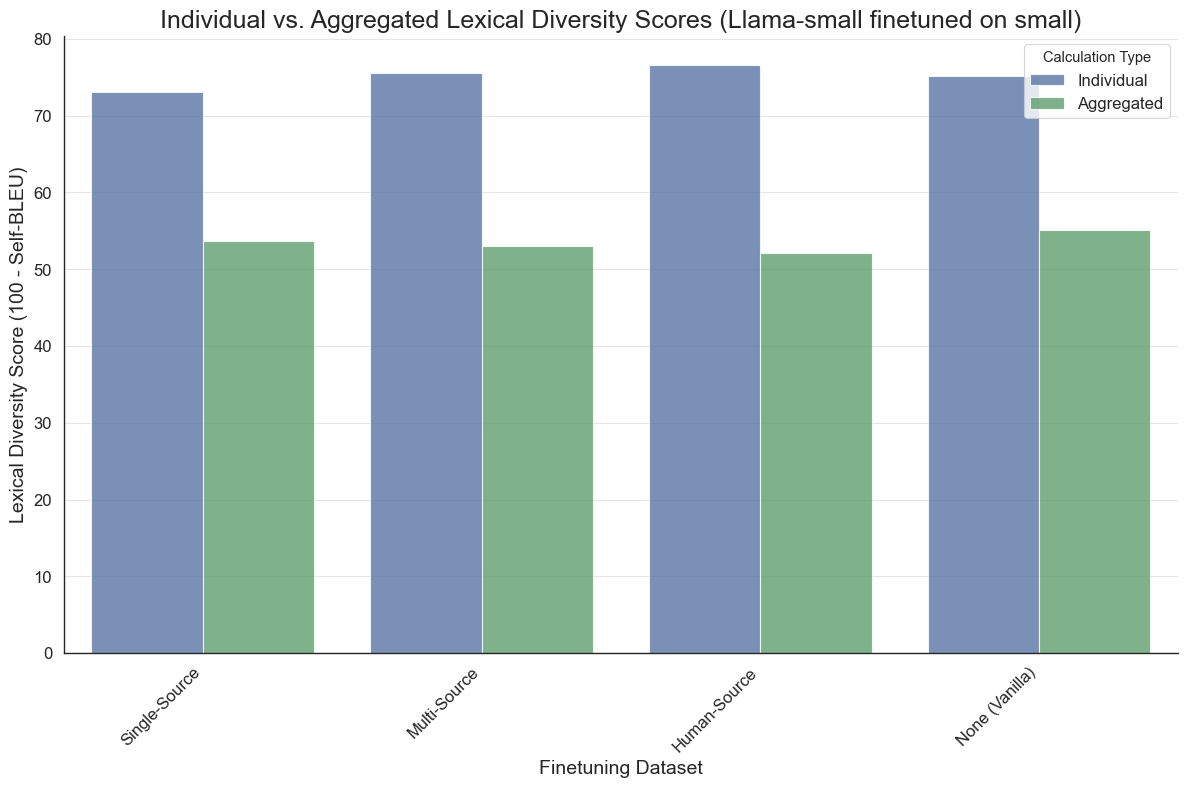


--- Lexical Diversity Statistics (Individual Responses) ---
Single-Source:
  Mean: 73.08, Median: 74.09, Std: 16.91
Multi-Source:
  Mean: 75.49, Median: 77.34, Std: 15.96
Human-Source:
  Mean: 76.55, Median: 85.19, Std: 21.91
None (Vanilla):
  Mean: 75.12, Median: 76.28, Std: 15.13

--- Kruskal-Wallis H-Test --- 
H-statistic: 66.20, p-value: 0.0000
Result: At least one dataset's distribution is significantly different (p < 0.05). Performing post-hoc tests.

Pairwise Mann-Whitney U Tests (Bonferroni corrected alpha=0.0083):
  Single-Source vs Multi-Source: U-stat=684885.5, p-value=3.861e-04 (Significant)
  Single-Source vs Human-Source: U-stat=406489.5, p-value=4.891e-14 (Significant)
  Single-Source vs None (Vanilla): U-stat=722436.5, p-value=7.736e-03 (Significant)
  Multi-Source vs Human-Source: U-stat=418100.0, p-value=4.738e-07 (Significant)
  Multi-Source vs None (Vanilla): U-stat=751943.5, p-value=2.892e-01
  Human-Source vs None (Vanilla): U-stat=577751.0, p-value=4.968e-10 (Si

In [18]:
# --- Configuration ---
MODEL_SIZE = "small"
BASE_DATA_DIR = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/{MODEL_SIZE}/lex_div"
N_GRAM = 3

# --- Data Loading ---
def load_bleu_data(base_path, mode, n_gram, size="Small"):
    """Loads Self-BLEU data from JSONL files into a DataFrame."""
    # Modified to remove 'size' from the path to match the new output structure
    data_dir = os.path.join(base_path, f"self_bleu_{mode}_{n_gram}")
    if not os.path.exists(data_dir):
        print(f"Directory not found: {data_dir}")
        return pd.DataFrame()
        
    records = []
    for filename in os.listdir(data_dir):
        if filename.endswith(".jsonl"):
            with open(os.path.join(data_dir, filename), 'r') as f:
                for line in f:
                    records.append(json.loads(line))
    return pd.DataFrame(records)

df_individual = load_bleu_data(BASE_DATA_DIR, 'individual', N_GRAM)
df_aggregated = load_bleu_data(BASE_DATA_DIR, 'aggregated', N_GRAM)

# --- Data Mapping and Sorting ---
def get_finetuning_dataset_name(source):
    """Maps a source name to a human-readable finetuning dataset name."""
    if 'single' in source:
        return 'Single-Source'
    if 'multi' in source:
        return 'Multi-Source'
    if 'human' in source:
        return 'Human-Source'
    if 'dolly' in source.lower():
        return 'None (Vanilla)'
    return 'Unknown'

df_individual['Finetuning Dataset'] = df_individual['source'].apply(get_finetuning_dataset_name)
df_aggregated['Finetuning Dataset'] = df_aggregated['source'].apply(get_finetuning_dataset_name)

category_order = ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)']

df_individual['Finetuning Dataset'] = pd.Categorical(df_individual['Finetuning Dataset'], categories=category_order, ordered=True)
df_aggregated['Finetuning Dataset'] = pd.Categorical(df_aggregated['Finetuning Dataset'], categories=category_order, ordered=True)

df_individual = df_individual.sort_values('Finetuning Dataset').reset_index(drop=True)
df_aggregated = df_aggregated.sort_values('Finetuning Dataset').reset_index(drop=True)

# --- Summary Table and CSV Export ---
# Merge individual and aggregated dataframes to create a comprehensive summary
summary_df = pd.merge(
    df_individual[['Finetuning Dataset', f'average_self_bleu_{N_GRAM}', 'average_lexical_diversity']],
    df_aggregated[['Finetuning Dataset', f'average_self_bleu_{N_GRAM}', 'average_lexical_diversity']],
    on='Finetuning Dataset',
    suffixes=('_individual', '_aggregated')
)

# Save the summary dataframe to a CSV file
output_csv_path = os.path.join(BASE_DATA_DIR, 'lexical_diversity_summary.csv')
summary_df.to_csv(output_csv_path, index=False)
print(f"--- Summary results saved to: {output_csv_path} ---")
print(summary_df.to_string(index=False))


# Rename columns for the display table
display_summary_df = summary_df.rename(columns={
    'average_lexical_diversity_individual': 'Individual Score',
    'average_lexical_diversity_aggregated': 'Aggregated Score'
})

# Select columns for the original summary table view
display_summary_df = display_summary_df[['Finetuning Dataset', 'Individual Score', 'Aggregated Score']]

print("\n--- Lexical Diversity Scores Summary ---")
print(display_summary_df.to_string(index=False))


# --- Visualization ---
plt.figure(figsize=(12, 8))
plot_data = pd.concat([
    df_individual.assign(type='Individual'),
    df_aggregated.assign(type='Aggregated')
])

sns.barplot(
    data=plot_data,
    x='Finetuning Dataset',
    y='average_lexical_diversity',
    hue='type',
    alpha=0.8,
    order=category_order
)

plt.title('Individual vs. Aggregated Lexical Diversity Scores (Llama-small finetuned on small)', fontsize=18)
plt.xlabel('Finetuning Dataset', fontsize=14)
plt.ylabel('Lexical Diversity Score (100 - Self-BLEU)', fontsize=14)
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=12
)
plt.yticks(fontsize=12)
plt.legend(title='Calculation Type', fontsize=12)
plt.tight_layout()
plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/small/bar_lex_div_8b_ind_aggr.png")
plt.show()


# --- Statistical Analysis ---
if 'lexical_diversity_scores' not in df_individual.columns:
    print("\nColumn 'lexical_diversity_scores' not found. Cannot perform detailed statistical analysis.")
else:
    lex_div_scores = df_individual['lexical_diversity_scores'].tolist()
    dataset_names = df_individual['Finetuning Dataset'].tolist()

    print("\n--- Lexical Diversity Statistics (Individual Responses) ---")
    scores_dict = {name: scores for name, scores in zip(dataset_names, lex_div_scores)}
    for name in category_order:
        scores = scores_dict.get(name)
        if scores is not None:
            mean, median, std = np.mean(scores), np.median(scores), np.std(scores)
            print(f"{name}:\n  Mean: {mean:.2f}, Median: {median:.2f}, Std: {std:.2f}")

    alpha = 0.05
    ordered_scores = [scores_dict[name] for name in category_order if name in scores_dict]

    '''
    if len(ordered_scores) > 1:
        levene_stat, levene_p = stats.levene(*ordered_scores)
        print(f"\n--- Levene's Test for Variance Homogeneity ---\nStatistic: {levene_stat:.2f}, p-value: {levene_p:.4f}")
        if levene_p < alpha:
            print(f"Result: Variances are significantly different (p < {alpha}). Performing pairwise tests.")
            
            print("\nPairwise Levene's Tests:")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.levene(scores_dict[name1], scores_dict[name2])
                    print(f"  {name1} vs {name2}: p-value = {p_val:.4f}{' (Significant)' if p_val < alpha else ''}")
        else:
            print(f"Result: Variances are not significantly different (p >= {alpha}).")
    '''
    
    # Kruskal-Wallis test
    if len(ordered_scores) > 1:
        kruskal_h, kruskal_p = stats.kruskal(*ordered_scores)
        print(f"\n--- Kruskal-Wallis H-Test --- \nH-statistic: {kruskal_h:.2f}, p-value: {kruskal_p:.4f}")
        if kruskal_p < alpha:
            print(f"Result: At least one dataset's distribution is significantly different (p < {alpha}). Performing post-hoc tests.")
            
            n_comparisons = len(category_order) * (len(category_order) - 1) // 2
            corrected_alpha = alpha / n_comparisons if n_comparisons > 0 else alpha
            
            print(f"\nPairwise Mann-Whitney U Tests (Bonferroni corrected alpha={corrected_alpha:.4f}):")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                 if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.mannwhitneyu(scores_dict[name1], scores_dict[name2], alternative='two-sided')
                    print(f"  {name1} vs {name2}: U-stat={stat:.1f}, p-value={p_val:.3e}{' (Significant)' if p_val < corrected_alpha else ''}")
        else:
            print(f"Result: No significant difference between dataset distributions (p >= {alpha}).")

## Medium models

### Calculate scores

In [22]:
# --- Configuration ---
N_GRAM = 3
SAMPLE_NUMBER = 1500
SAVE_RESULTS = True
MODEL_SIZE = "medium"
FINETUNE_SIZE = "large"
BASE_DATA_DIR = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1"

# Using new, corrected file paths
model_paths = {
    "Medium": [
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_llama_70b_single_source_{FINETUNE_SIZE}.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_llama_70b_multi_source_{FINETUNE_SIZE}.jsonl",
        f"{BASE_DATA_DIR}/{MODEL_SIZE}/outputs/output_llama_70b_human_source.jsonl",
        "/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_test_Llama.jsonl"
    ]
}

output_dir_template = f"{BASE_DATA_DIR}/{MODEL_SIZE}/lex_div/self_bleu_{{mode}}_{{n_gram}}_{FINETUNE_SIZE}"

# --- Run Calculations ---
# Calculate scores for individual responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='individual',
    sample_number=SAMPLE_NUMBER,
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

# Calculate scores for aggregated responses
calculate_self_bleu_scores(
    data_paths=model_paths,
    output_dir_template=output_dir_template,
    mode='aggregated',
    sample_number=100,  # Using 100 for aggregated as in original code
    save=SAVE_RESULTS,
    n_gram=N_GRAM
)

--- Running Self-BLEU Calculation (Mode: individual, N-gram: 3) ---
Processing Medium models...


  Files for Medium:   0%|          | 0/4 [00:00<?, ?it/s]

  Files for Medium:  25%|██▌       | 1/4 [00:05<00:16,  5.67s/it]

  Files for Medium:  50%|█████     | 2/4 [00:14<00:14,  7.46s/it]

  Files for Medium:  75%|███████▌  | 3/4 [00:16<00:04,  4.90s/it]

  Files for Medium: 100%|██████████| 4/4 [00:22<00:00,  5.68s/it]


--- Calculation complete. ---
--- Running Self-BLEU Calculation (Mode: aggregated, N-gram: 3) ---
Processing Medium models...


  Files for Medium: 100%|██████████| 4/4 [02:28<00:00, 37.25s/it]

--- Calculation complete. ---


### Statistics & plotting

--- Summary results saved to: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/lex_div/lexical_diversity_summary_large.csv ---

--- Lexical Diversity Scores Summary (for display) ---
Finetuning Dataset  Individual Score  Aggregated Score
     Single-Source         77.540968         57.206718
      Multi-Source         78.768981         61.683060
      Human-Source         80.559722         61.461994
    None (Vanilla)         78.109452         58.386605


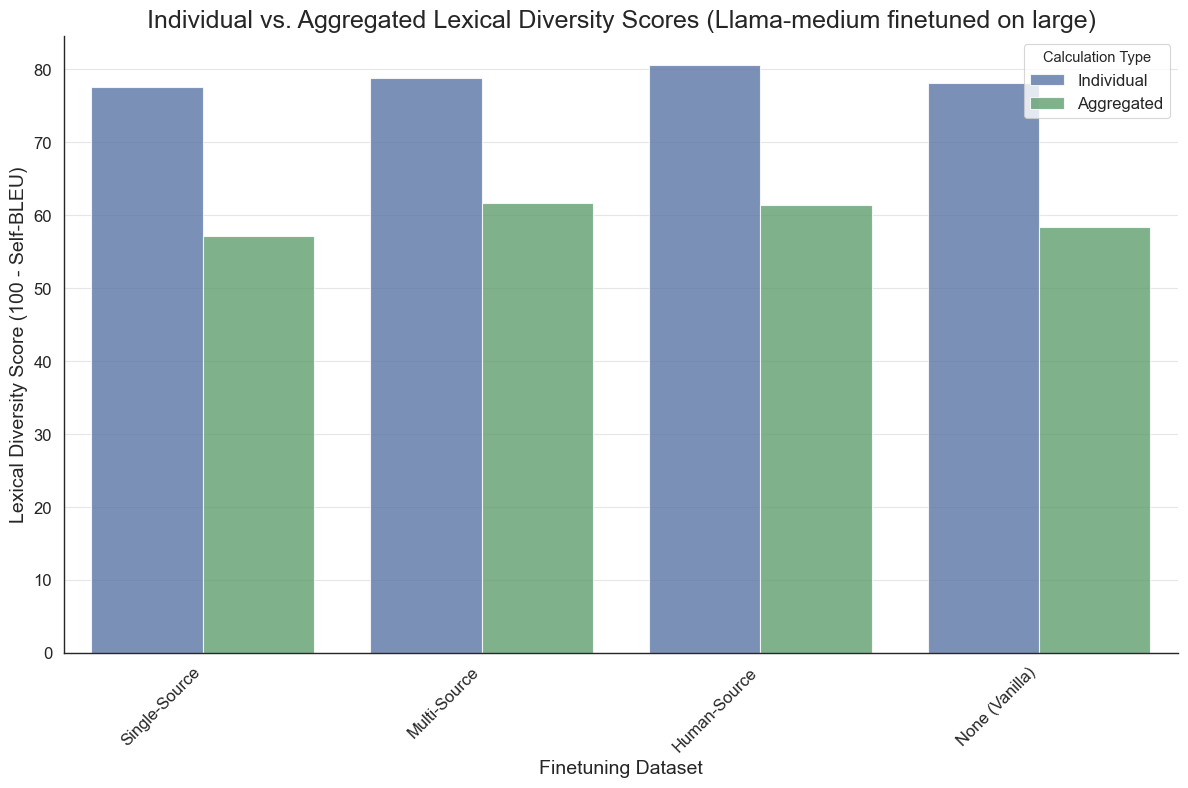


--- Lexical Diversity Statistics (Individual Responses) ---
Single-Source:
  Mean: 77.54, Median: 79.16, Variance: 200.11
Multi-Source:
  Mean: 78.77, Median: 80.36, Variance: 191.64
Human-Source:
  Mean: 80.56, Median: 86.87, Variance: 309.08
None (Vanilla):
  Mean: 78.11, Median: 78.94, Variance: 172.67

--- Kruskal-Wallis H-Test --- 
H-statistic: 65.02, p-value: 0.0000
Result: At least one dataset's distribution is significantly different (p < 0.05). Performing post-hoc tests.

Pairwise Mann-Whitney U Tests (Bonferroni corrected alpha=0.0083):
  Single-Source vs Multi-Source: U-stat=614778.5, p-value=2.630e-02
  Single-Source vs Human-Source: U-stat=350377.5, p-value=7.475e-13 (Significant)
  Single-Source vs None (Vanilla): U-stat=680877.0, p-value=6.922e-01
  Multi-Source vs Human-Source: U-stat=344756.0, p-value=1.682e-08 (Significant)
  Multi-Source vs None (Vanilla): U-stat=675735.5, p-value=4.731e-02
  Human-Source vs None (Vanilla): U-stat=514163.0, p-value=1.794e-12 (Signif

In [26]:
# --- Configuration ---
MODEL_SIZE = "medium"
FINETUNE_SIZE = "large"
SAVE_PLOT = True
BASE_DATA_DIR = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/{MODEL_SIZE}/lex_div"
N_GRAM = 3

# --- Data Loading ---
def load_bleu_data(base_path, mode, n_gram, size="Medium"):
    """Loads Self-BLEU data from JSONL files into a DataFrame."""
    # Corrected path to remove the 'size' subdirectory
    data_dir = os.path.join(base_path, f"self_bleu_{mode}_{n_gram}_{FINETUNE_SIZE}")
    if not os.path.exists(data_dir):
        print(f"Directory not found: {data_dir}")
        return pd.DataFrame()
        
    records = []
    for filename in os.listdir(data_dir):
        if filename.endswith(".jsonl"):
            with open(os.path.join(data_dir, filename), 'r') as f:
                for line in f:
                    records.append(json.loads(line))
    return pd.DataFrame(records)

df_individual = load_bleu_data(BASE_DATA_DIR, 'individual', N_GRAM)
df_aggregated = load_bleu_data(BASE_DATA_DIR, 'aggregated', N_GRAM)

# --- Data Mapping and Sorting ---
def get_finetuning_dataset_name(source):
    """Maps a source name to a human-readable finetuning dataset name."""
    if 'single_source' in source:
        return 'Single-Source'
    if 'multi_source' in source:
        return 'Multi-Source'
    if 'human_source' in source:
        return 'Human-Source'
    if 'dolly' in source.lower(): # Check for 'dolly' case-insensitively
        return 'None (Vanilla)'
    return 'Unknown' # Fallback for any other cases

# Apply the mapping to create a new column
df_individual['Finetuning Dataset'] = df_individual['source'].apply(get_finetuning_dataset_name)
df_aggregated['Finetuning Dataset'] = df_aggregated['source'].apply(get_finetuning_dataset_name)

# Define the desired order for plotting
category_order = ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)']

# Set the category type with the specified order to ensure correct sorting in plots
df_individual['Finetuning Dataset'] = pd.Categorical(df_individual['Finetuning Dataset'], categories=category_order, ordered=True)
df_aggregated['Finetuning Dataset'] = pd.Categorical(df_aggregated['Finetuning Dataset'], categories=category_order, ordered=True)

# Sort the dataframes based on the new categorical column
df_individual = df_individual.sort_values('Finetuning Dataset').reset_index(drop=True)
df_aggregated = df_aggregated.sort_values('Finetuning Dataset').reset_index(drop=True)


# --- Summary Table and CSV Export ---
# Merge individual and aggregated dataframes to create a comprehensive summary
summary_df = pd.merge(
    df_individual[['Finetuning Dataset', f'average_self_bleu_{N_GRAM}', 'average_lexical_diversity']],
    df_aggregated[['Finetuning Dataset', f'average_self_bleu_{N_GRAM}', 'average_lexical_diversity']],
    on='Finetuning Dataset',
    suffixes=('_individual', '_aggregated')
)

# Save the complete summary dataframe to a CSV file
output_csv_path = os.path.join(BASE_DATA_DIR, f'lexical_diversity_summary_{FINETUNE_SIZE}.csv')
summary_df.to_csv(output_csv_path, index=False)
print(f"--- Summary results saved to: {output_csv_path} ---")


# For display, create a cleaner table with just lexical diversity scores
display_summary_df = pd.merge(
    df_individual[['Finetuning Dataset', 'average_lexical_diversity']],
    df_aggregated[['Finetuning Dataset', 'average_lexical_diversity']],
    on='Finetuning Dataset',
    suffixes=('_individual', '_aggregated')
)

# Rename columns for clarity
display_summary_df.rename(columns={
    'average_lexical_diversity_individual': 'Individual Score',
    'average_lexical_diversity_aggregated': 'Aggregated Score'
}, inplace=True)

# Reorder columns and print the final table for display
display_summary_df = display_summary_df[['Finetuning Dataset', 'Individual Score', 'Aggregated Score']]

print("\n--- Lexical Diversity Scores Summary (for display) ---")
print(display_summary_df.to_string(index=False))


# --- Visualization ---
plt.figure(figsize=(12, 8))
plot_data = pd.concat([
    df_individual.assign(type='Individual'),
    df_aggregated.assign(type='Aggregated')
])

sns.barplot(
    data=plot_data,
    x='Finetuning Dataset', # Use the new column for x-axis
    y='average_lexical_diversity',
    hue='type',
    alpha=0.8,
    order=category_order # Ensure barplot uses the correct order
)

plt.title(f'Individual vs. Aggregated Lexical Diversity Scores (Llama-{MODEL_SIZE} finetuned on {FINETUNE_SIZE})', fontsize=18)
plt.xlabel('Finetuning Dataset', fontsize=14)
plt.ylabel('Lexical Diversity Score (100 - Self-BLEU)', fontsize=14)
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=12
)
plt.yticks(fontsize=12)
plt.legend(title='Calculation Type', fontsize=12)
plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/bar_lex_div_70b_ind_aggr_{FINETUNE_SIZE}.png")
plt.show()


# --- Statistical Analysis ---
# Ensure 'lexical_diversity_scores' exists before proceeding
if 'lexical_diversity_scores' not in df_individual.columns:
    print("\nColumn 'lexical_diversity_scores' not found. Cannot perform detailed statistical analysis.")
else:
    # Use the 'Finetuning Dataset' column for names, ensuring it's in the correct order
    lex_div_scores = df_individual['lexical_diversity_scores'].tolist()
    dataset_names = df_individual['Finetuning Dataset'].tolist()

    print("\n--- Lexical Diversity Statistics (Individual Responses) ---")
    # Create a mapping from dataset name to scores for correct association
    scores_dict = {name: scores for name, scores in zip(dataset_names, lex_div_scores)}
    for name in category_order: # Iterate in the desired order
        scores = scores_dict.get(name)
        if scores is not None:
            mean, median, var = np.mean(scores), np.median(scores), np.var(scores)
            print(f"{name}:\n  Mean: {mean:.2f}, Median: {median:.2f}, Variance: {var:.2f}")

    alpha = 0.05

    # Order scores for statistical tests according to category_order
    ordered_scores = [scores_dict[name] for name in category_order if name in scores_dict]

    '''
    # Levene's test for homogeneity of variances
    if len(ordered_scores) > 1:
        levene_stat, levene_p = stats.levene(*ordered_scores)
        print(f"\n--- Levene's Test for Variance Homogeneity ---\nStatistic: {levene_stat:.2f}, p-value: {levene_p:.4f}")
        if levene_p < alpha:
            print(f"Result: Variances are significantly different (p < {alpha}). Performing pairwise tests.")
            
            print("\nPairwise Levene's Tests:")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.levene(scores_dict[name1], scores_dict[name2])
                    print(f"  {name1} vs {name2}: p-value = {p_val:.4f}{' (Significant)' if p_val < alpha else ''}")

        else:
            print(f"Result: Variances are not significantly different (p >= {alpha}).")
    '''

    # Kruskal-Wallis H-test for comparing distributions
    if len(ordered_scores) > 1:
        kruskal_h, kruskal_p = stats.kruskal(*ordered_scores)
        print(f"\n--- Kruskal-Wallis H-Test --- \nH-statistic: {kruskal_h:.2f}, p-value: {kruskal_p:.4f}")
        if kruskal_p < alpha:
            print(f"Result: At least one dataset's distribution is significantly different (p < {alpha}). Performing post-hoc tests.")
            
            n_comparisons = len(category_order) * (len(category_order) - 1) // 2
            corrected_alpha = alpha / n_comparisons if n_comparisons > 0 else alpha
            
            print(f"\nPairwise Mann-Whitney U Tests (Bonferroni corrected alpha={corrected_alpha:.4f}):")
            for (name1), (name2) in itertools.combinations(category_order, 2):
                 if name1 in scores_dict and name2 in scores_dict:
                    stat, p_val = stats.mannwhitneyu(scores_dict[name1], scores_dict[name2], alternative='two-sided')
                    print(f"  {name1} vs {name2}: U-stat={stat:.1f}, p-value={p_val:.3e}{' (Significant)' if p_val < corrected_alpha else ''}")

        else:
            print(f"Result: No significant difference between dataset distributions (p >= {alpha}).")

### Statistical significance: Different fine-tuning data sizes

In [68]:
import json
from scipy import stats
import itertools
import numpy as np

def load_scores_from_file(file_path):
    """Loads the 'lexical_diversity_scores' from a single-line JSONL file."""
    with open(file_path, 'r') as f:
        data = json.load(f)
        return data.get("lexical_diversity_scores", [])

def run_statistical_comparison(file_group, group_name):
    """
    Runs Kruskal-Wallis and post-hoc Mann-Whitney U tests on a group of files.
    """
    print(f"--- Running Analysis for: {group_name} ---")

    # Reordered labels to Small, Medium, Large
    labels = [
        'Small Finetune Data', 
        'Medium Finetune Data', 
        'Large Finetune Data'
    ]
    
    # Load the scores from each file
    scores_data = [load_scores_from_file(path) for path in file_group]
    
    if not all(scores_data):
        print("Error: Could not load scores from one or more files. Aborting analysis.")
        return

    # --- Calculate and Print Mean Scores ---
    print("\nMean Lexical Diversity Scores:")
    for label, scores in zip(labels, scores_data):
        if scores:
            mean_score = np.mean(scores)
            print(f"  - {label}: {mean_score:.2f}")

    # --- Kruskal-Wallis H-Test ---
    kruskal_h, kruskal_p = stats.kruskal(*scores_data)
    print(f"\nKruskal-Wallis H-Test Results:")
    print(f"  H-statistic: {kruskal_h:.2f}")
    print(f"  p-value: {kruskal_p:.4f}")

    # --- Post-Hoc Pairwise Tests (if Kruskal-Wallis is significant) ---
    alpha = 0.05
    if kruskal_p < alpha:
        print(f"\nResult: A significant difference exists between the groups (p < {alpha}).")
        print("Performing pairwise Mann-Whitney U tests to find where the differences lie.")
        
        n_comparisons = 3
        corrected_alpha = alpha / n_comparisons
        print(f"(Using Bonferroni corrected alpha = {corrected_alpha:.4f} for pairwise tests)")

        pairwise_combinations = itertools.combinations(zip(labels, scores_data), 2)

        print("\nPairwise Mann-Whitney U Test Results:")
        for (label1, data1), (label2, data2) in pairwise_combinations:
            stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            
            significance_marker = " (Significant)" if p_val < corrected_alpha else ""
            print(f"  - {label1} vs {label2}:")
            print(f"    U-statistic = {stat:.1f}, p-value = {p_val:.3e}{significance_marker}")
    else:
        print(f"\nResult: No significant difference was found between the groups (p >= {alpha}).")
    print("-" * 50 + "\n")


# --- Define File Groups (Reordered to Small, Medium, Large) ---

# Group 1: Single-Source comparisons
single_source_files = [
    '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/lex_div/self_bleu_individual_3_small/output_llama_70b_single_source_small_self_bleu.jsonl',
    '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/lex_div/self_bleu_individual_3_medium/output_llama_70b_single_source_medium_self_bleu.jsonl',
    '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/lex_div/self_bleu_individual_3_large/output_llama_70b_single_source_large_self_bleu.jsonl'
]

# Group 2: Multi-Source comparisons
multi_source_files = [
    '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/lex_div/self_bleu_individual_3_small/output_llama_70b_multi_source_small_self_bleu.jsonl',
    '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/lex_div/self_bleu_individual_3_medium/output_llama_70b_multi_source_medium_self_bleu.jsonl',
    '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/lex_div/self_bleu_individual_3_large/output_llama_70b_multi_source_large_self_bleu.jsonl'
]


# --- Run Analyses ---
run_statistical_comparison(single_source_files, "Single-Source Models")
run_statistical_comparison(multi_source_files, "Multi-Source Models")

--- Running Analysis for: Single-Source Models ---

Mean Lexical Diversity Scores:
  - Small Finetune Data: 73.83
  - Medium Finetune Data: 75.80
  - Large Finetune Data: 77.54

Kruskal-Wallis H-Test Results:
  H-statistic: 32.50
  p-value: 0.0000

Result: A significant difference exists between the groups (p < 0.05).
Performing pairwise Mann-Whitney U tests to find where the differences lie.
(Using Bonferroni corrected alpha = 0.0167 for pairwise tests)

Pairwise Mann-Whitney U Test Results:
  - Small Finetune Data vs Medium Finetune Data:
    U-statistic = 620952.5, p-value = 1.159e-02 (Significant)
  - Small Finetune Data vs Large Finetune Data:
    U-statistic = 606135.5, p-value = 2.558e-08 (Significant)
  - Medium Finetune Data vs Large Finetune Data:
    U-statistic = 603192.0, p-value = 9.297e-04 (Significant)
--------------------------------------------------

--- Running Analysis for: Multi-Source Models ---

Mean Lexical Diversity Scores:
  - Small Finetune Data: 75.07
  - M

### Saving all metrics to csv

In [ ]:
import pandas as pd
import os
import json

# --- Configuration ---
# List of all finetuning sizes you want to include in the summary
FINETUNE_SIZES = ["small", "medium", "large"]
MODEL_SIZE = "medium"
N_GRAM = 3
BASE_DATA_DIR = f"/Users/maxschaffelder/Desktop/Thesis/data/exp_1/{MODEL_SIZE}/lex_div"


# --- Helper Functions (to make this cell self-contained) ---

def load_bleu_data(base_path, mode, n_gram, finetune_size):
    """Loads Self-BLEU data from JSONL files into a DataFrame."""
    data_dir = os.path.join(base_path, f"self_bleu_{mode}_{n_gram}_{finetune_size}")
    if not os.path.exists(data_dir):
        print(f"Warning: Directory not found, skipping: {data_dir}")
        return pd.DataFrame()
        
    records = []
    for filename in os.listdir(data_dir):
        if filename.endswith(".jsonl"):
            with open(os.path.join(data_dir, filename), 'r') as f:
                for line in f:
                    records.append(json.loads(line))
    return pd.DataFrame(records)

def get_finetuning_dataset_name(source):
    """Maps a source name to a human-readable finetuning dataset name."""
    if 'single_source' in source:
        return 'Single-Source'
    if 'multi_source' in source:
        return 'Multi-Source'
    if 'human_source' in source:
        return 'Human-Source'
    if 'dolly' in source.lower():
        return 'None (Vanilla)'
    return 'Unknown'


# --- Main Logic ---

all_summaries = []

print("--- Starting data consolidation for all finetune sizes ---")

for ft_size in FINETUNE_SIZES:
    print(f"Processing finetune size: '{ft_size}'...")
    
    # Load individual and aggregated data for the current finetune size
    df_individual = load_bleu_data(BASE_DATA_DIR, 'individual', N_GRAM, ft_size)
    df_aggregated = load_bleu_data(BASE_DATA_DIR, 'aggregated', N_GRAM, ft_size)

    # If either dataframe is empty (e.g., directory not found), skip this finetune size
    if df_individual.empty or df_aggregated.empty:
        print(f"Skipping '{ft_size}' due to missing data.")
        continue

    # Map source filenames to readable names
    df_individual['Finetuning Dataset'] = df_individual['source'].apply(get_finetuning_dataset_name)
    df_aggregated['Finetuning Dataset'] = df_aggregated['source'].apply(get_finetuning_dataset_name)

    # Merge the dataframes
    summary_df = pd.merge(
        df_individual[['Finetuning Dataset', f'average_self_bleu_{N_GRAM}', 'average_lexical_diversity']],
        df_aggregated[['Finetuning Dataset', f'average_self_bleu_{N_GRAM}', 'average_lexical_diversity']],
        on='Finetuning Dataset',
        suffixes=('_individual', '_aggregated')
    )
    
    # Add a column to identify the finetuning size
    summary_df['Finetune Size'] = ft_size
    
    all_summaries.append(summary_df)

# --- Final Consolidation and Saving ---

if all_summaries:
    # Concatenate all the dataframes into a single one
    final_summary_df = pd.concat(all_summaries, ignore_index=True)
    
    # Reorder columns to have 'Finetune Size' first
    cols = ['Finetune Size', 'Finetuning Dataset'] + [c for c in final_summary_df.columns if c not in ['Finetune Size', 'Finetuning Dataset']]
    final_summary_df = final_summary_df[cols]

    # Save the final combined dataframe to a CSV file
    output_csv_path = os.path.join(BASE_DATA_DIR, 'lexical_diversity_summary_all_finetunes.csv')
    final_summary_df.to_csv(output_csv_path, index=False)
    
    print(f"\n--- All metrics successfully saved to: {output_csv_path} ---")
    
    # Display the final table
    print("\n--- Combined Summary Table ---")
    print(final_summary_df.to_string())
else:
    print("\n--- No data found to process. ---")

# Combined Visualization

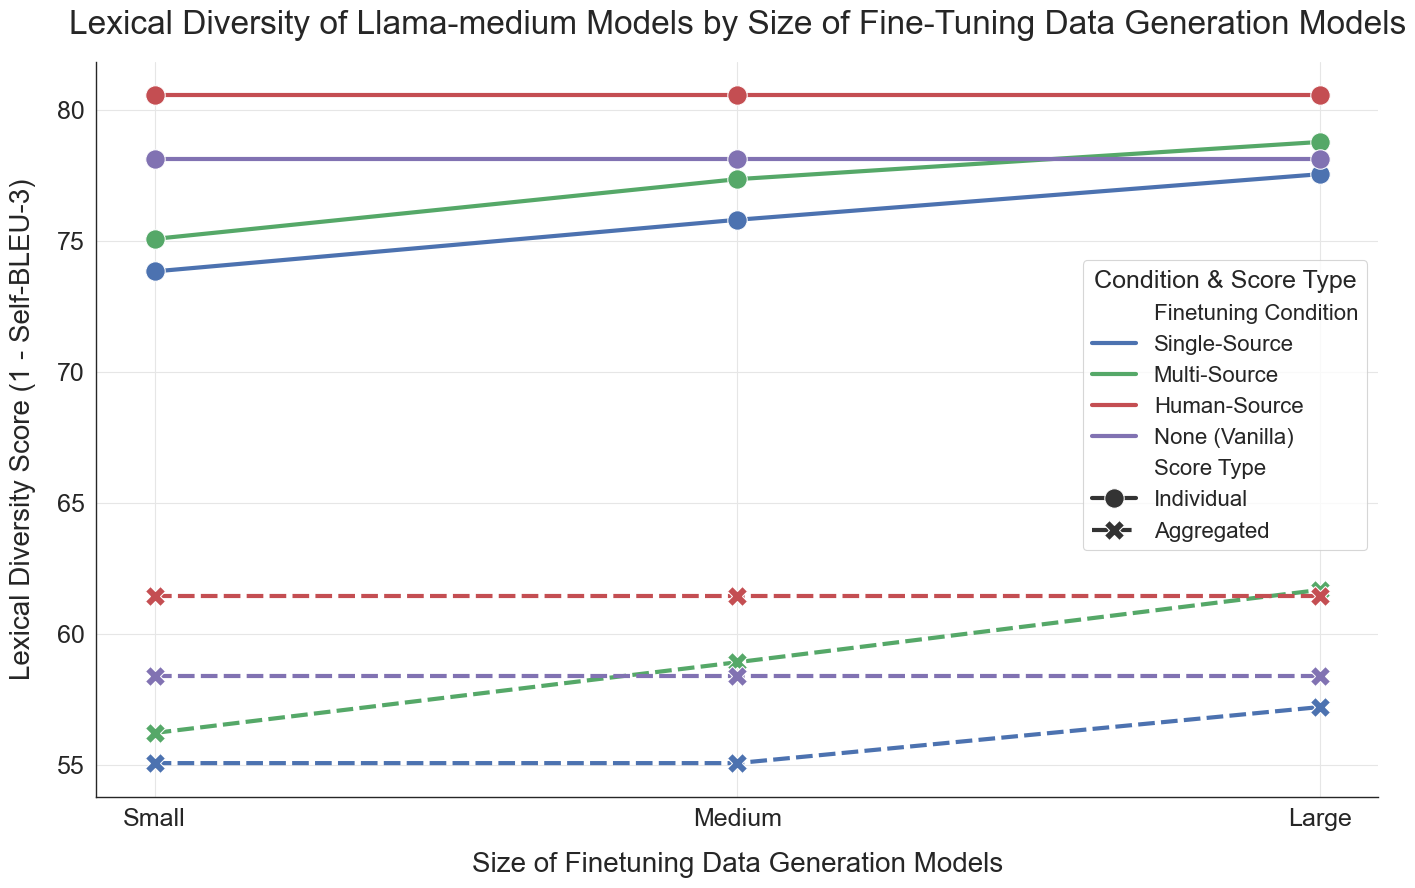

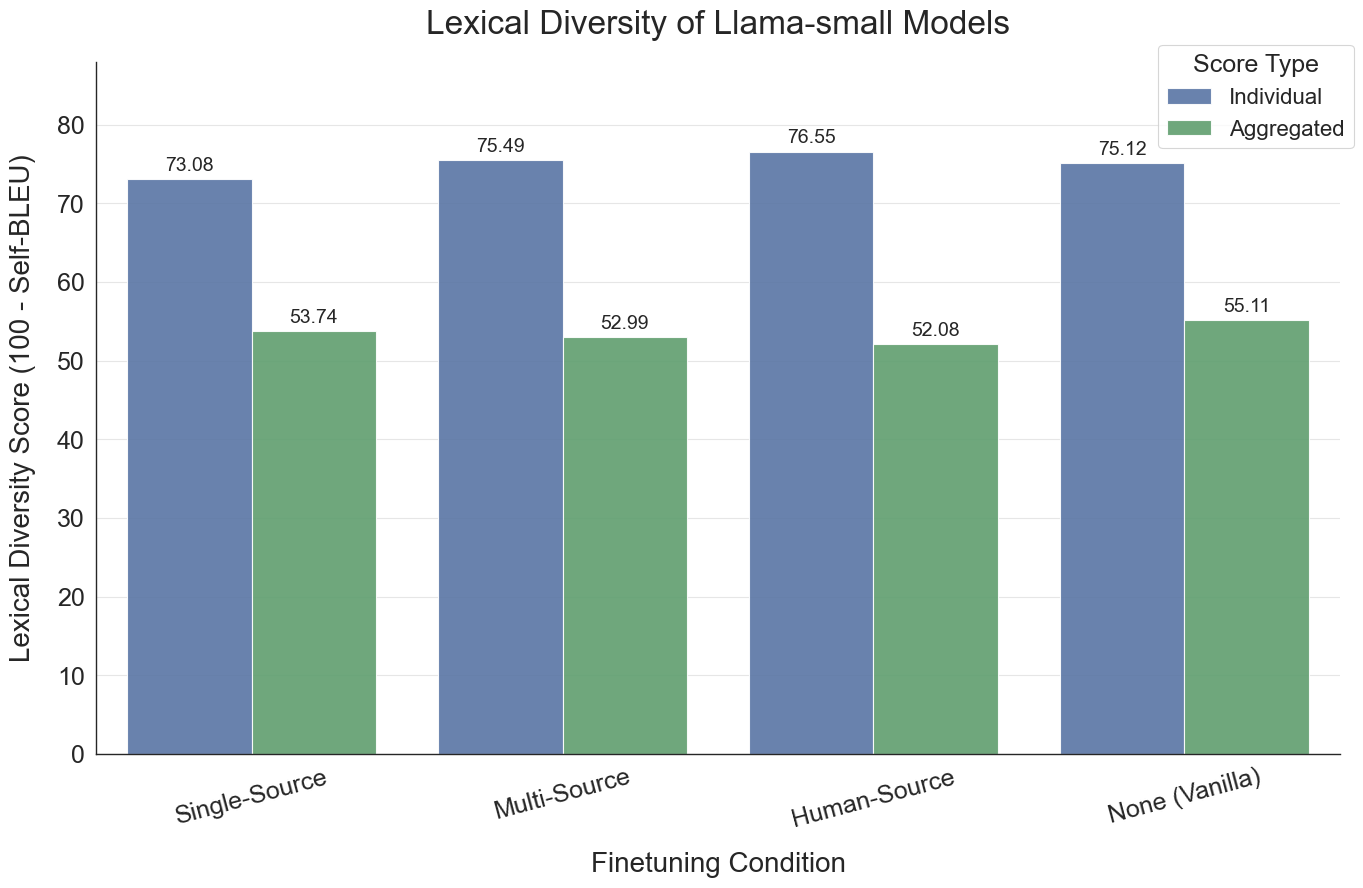

In [2]:
# --- 1. Prepare the DataFrame (same as before) ---
data = {
    'Model': [
        # Llama-small data
        'Llama-small', 'Llama-small', 'Llama-small', 'Llama-small', 
        'Llama-small', 'Llama-small', 'Llama-small', 'Llama-small',
        # Llama-medium data (Single-Source)
        'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium',
        # Llama-medium data (Multi-Source)
        'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium',
        # Llama-medium baselines (repeated for plotting)
        'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium',
        'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium',
        'Llama-medium', 'Llama-medium', 'Llama-medium', 'Llama-medium'
    ],
    'Finetuning Condition': [
        # Llama-small
        'Single-Source', 'Single-Source', 'Multi-Source', 'Multi-Source', 
        'Human-Source', 'Human-Source', 'None (Vanilla)', 'None (Vanilla)',
        # Llama-medium (Single-Source)
        'Single-Source', 'Single-Source', 'Single-Source', 'Single-Source', 'Single-Source', 'Single-Source',
        # Llama-medium (Multi-Source)
        'Multi-Source', 'Multi-Source', 'Multi-Source', 'Multi-Source', 'Multi-Source', 'Multi-Source',
        # Llama-medium baselines
        'Human-Source', 'Human-Source', 'None (Vanilla)', 'None (Vanilla)', # Small
        'Human-Source', 'Human-Source', 'None (Vanilla)', 'None (Vanilla)', # Medium
        'Human-Source', 'Human-Source', 'None (Vanilla)', 'None (Vanilla)'  # Large
    ],
    'Finetuning Data Size': [
        # Llama-small
        'Small', 'Small', 'Small', 'Small', 'Small', 'Small', 'Small', 'Small',
        # Llama-medium (Single-Source)
        'Small', 'Small', 'Medium', 'Medium', 'Large', 'Large',
        # Llama-medium (Multi-Source)
        'Small', 'Small', 'Medium', 'Medium', 'Large', 'Large',
        # Llama-medium baselines
        'Small', 'Small', 'Small', 'Small', 
        'Medium', 'Medium', 'Medium', 'Medium',
        'Large', 'Large', 'Large', 'Large'
    ],
    'Score Type': [
        'Individual', 'Aggregated'] * 4 + 
        ['Individual', 'Aggregated'] * 3 + 
        ['Individual', 'Aggregated'] * 3 +
        ['Individual', 'Aggregated'] * 2 * 3,
    'Score': [
        # Llama-small
        73.08, 53.74, 75.49, 52.99, 76.55, 52.08, 75.12, 55.11,
        # Llama-medium (Single-Source)
        73.83, 55.07, 75.80, 55.07, 77.54, 57.21,
        # Llama-medium (Multi-Source)
        75.07, 56.22, 77.35, 58.92, 78.77, 61.68,
        # Llama-medium baselines
        80.56, 61.46, 78.11, 58.39, # Small
        80.56, 61.46, 78.11, 58.39, # Medium
        80.56, 61.46, 78.11, 58.39  # Large
    ]
}

df = pd.DataFrame(data)
df['Finetuning Data Size'] = pd.Categorical(df['Finetuning Data Size'], categories=['Small', 'Medium', 'Large'], ordered=True)
df['Finetuning Condition'] = pd.Categorical(df['Finetuning Condition'], categories=['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'], ordered=True)

# Define the custom color palette using the first four colors from your style guide
custom_palette = {
    "Single-Source": "#4C72B0",  # blue
    "Multi-Source": "#55A868",   # green
    "Human-Source": "#C44E52",   # red
    "None (Vanilla)": "#8172B2"  # purple
}

# --- 2. Plotting for Llama-medium (Styled Line Chart with Larger Fonts) ---
df_medium = df[df['Model'] == 'Llama-medium'].copy()

plt.figure(figsize=(14, 9))
ax_line = sns.lineplot(
    data=df_medium,
    x='Finetuning Data Size',
    y='Score',
    hue='Finetuning Condition',
    style='Score Type',
    markers=True,
    markersize=14,
    linewidth=3,
    palette=custom_palette # Apply your custom color palette
)

ax_line.set_title('Lexical Diversity of Llama-medium Models by Size of Fine-Tuning Data Generation Models', fontsize=24, pad=20)
ax_line.set_xlabel('Size of Finetuning Data Generation Models', fontsize=20, labelpad=15)
ax_line.set_ylabel('Lexical Diversity Score (1 - Self-BLEU-3)', fontsize=20, labelpad=15)
ax_line.tick_params(axis='both', which='major', labelsize=18)

# Place legend in lower right and nudge it slightly up and to the left from the corner
legend = plt.legend(title='Condition & Score Type', loc='lower right', bbox_to_anchor=(1, 0.32), fontsize=16)
plt.setp(legend.get_title(), fontsize=18)

plt.tight_layout()
#plt.savefig('/Users/maxschaffelder/Desktop/line_lex_div_llama_medium_summary.png', dpi=300, bbox_inches='tight')
plt.show()



# --- 3. Plotting for Llama-small (Styled Grouped Bar Chart with Larger Fonts) ---
df_small = df[df['Model'] == 'Llama-small'].copy()

# A different palette for the two score types in the bar chart
bar_palette = {
    'Individual': '#4c72b0', # Blue
    'Aggregated': '#55a868'  # Green
}

plt.figure(figsize=(14, 9))
ax_bar = sns.barplot(
    data=df_small,
    x='Finetuning Condition',
    y='Score',
    hue='Score Type',
    palette=bar_palette,
    alpha=0.9
    # edgecolor has been removed
)

# Add value labels on top of each bar, ONLY if the bar's height is > 0
for p in ax_bar.patches:
    if p.get_height() > 0:  # This condition prevents the "0.00" label
        ax_bar.annotate(format(p.get_height(), '.2f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 10), 
                       textcoords='offset points',
                       fontsize=14)

ax_bar.set_title('Lexical Diversity of Llama-small Models', fontsize=24, pad=20)
ax_bar.set_xlabel('Finetuning Condition', fontsize=20, labelpad=15)
ax_bar.set_ylabel('Lexical Diversity Score (100 - Self-BLEU)', fontsize=20, labelpad=15)
ax_bar.tick_params(axis='x', labelsize=18, rotation=15)
ax_bar.tick_params(axis='y', labelsize=18)
ax_bar.set_ylim(0, df_small['Score'].max() * 1.15)

# Nudge the legend slightly to the right from the default 'upper left' position
legend = plt.legend(title='Score Type', loc='upper left', bbox_to_anchor=(0.845, 1.04), fontsize=16)
plt.setp(legend.get_title(), fontsize=18)

plt.tight_layout()
#plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/small/bar_lex_div_llama_small.png', dpi=300, bbox_inches='tight')
plt.show()

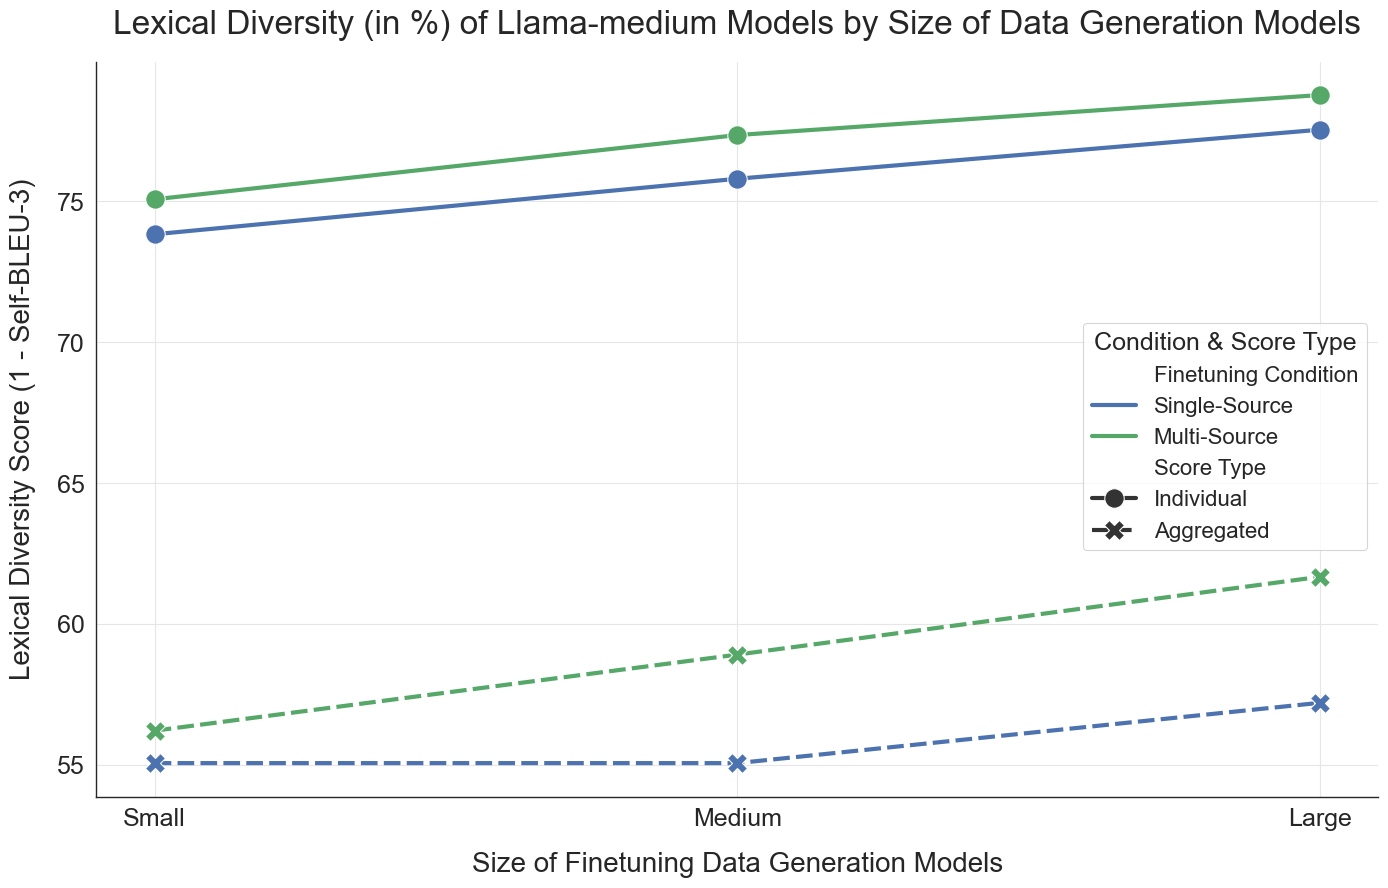

In [6]:
# --- 2. Plotting for Llama-medium (Styled Line Chart with Larger Fonts) ---
df_medium = df[df['Model'] == 'Llama-medium'].copy()
# Filter out 'Human-Source' and 'None (Vanilla)'
df_medium = df_medium[~df_medium['Finetuning Condition'].isin(['Human-Source', 'None (Vanilla)'])]
# Remove unused categories to ensure the legend is also filtered
df_medium['Finetuning Condition'] = df_medium['Finetuning Condition'].cat.remove_unused_categories()

plt.figure(figsize=(14, 9))
ax_line = sns.lineplot(
    data=df_medium,
    x='Finetuning Data Size',
    y='Score',
    hue='Finetuning Condition',
    style='Score Type',
    markers=True,
    markersize=14,
    linewidth=3,
    palette=custom_palette # Apply your custom color palette
)

ax_line.set_title('Lexical Diversity (in %) of Llama-medium Models by Size of Data Generation Models', fontsize=24, pad=20)
ax_line.set_xlabel('Size of Finetuning Data Generation Models', fontsize=20, labelpad=15)
ax_line.set_ylabel('Lexical Diversity Score (1 - Self-BLEU-3)', fontsize=20, labelpad=15)
ax_line.tick_params(axis='both', which='major', labelsize=18)

# Place legend in lower right and nudge it slightly up and to the left from the corner
legend = plt.legend(title='Condition & Score Type', loc='lower right', bbox_to_anchor=(1, 0.32), fontsize=16)
plt.setp(legend.get_title(), fontsize=18)

plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/line_lex_div_llama_medium_no_human.png', dpi=300, bbox_inches='tight')
plt.show()

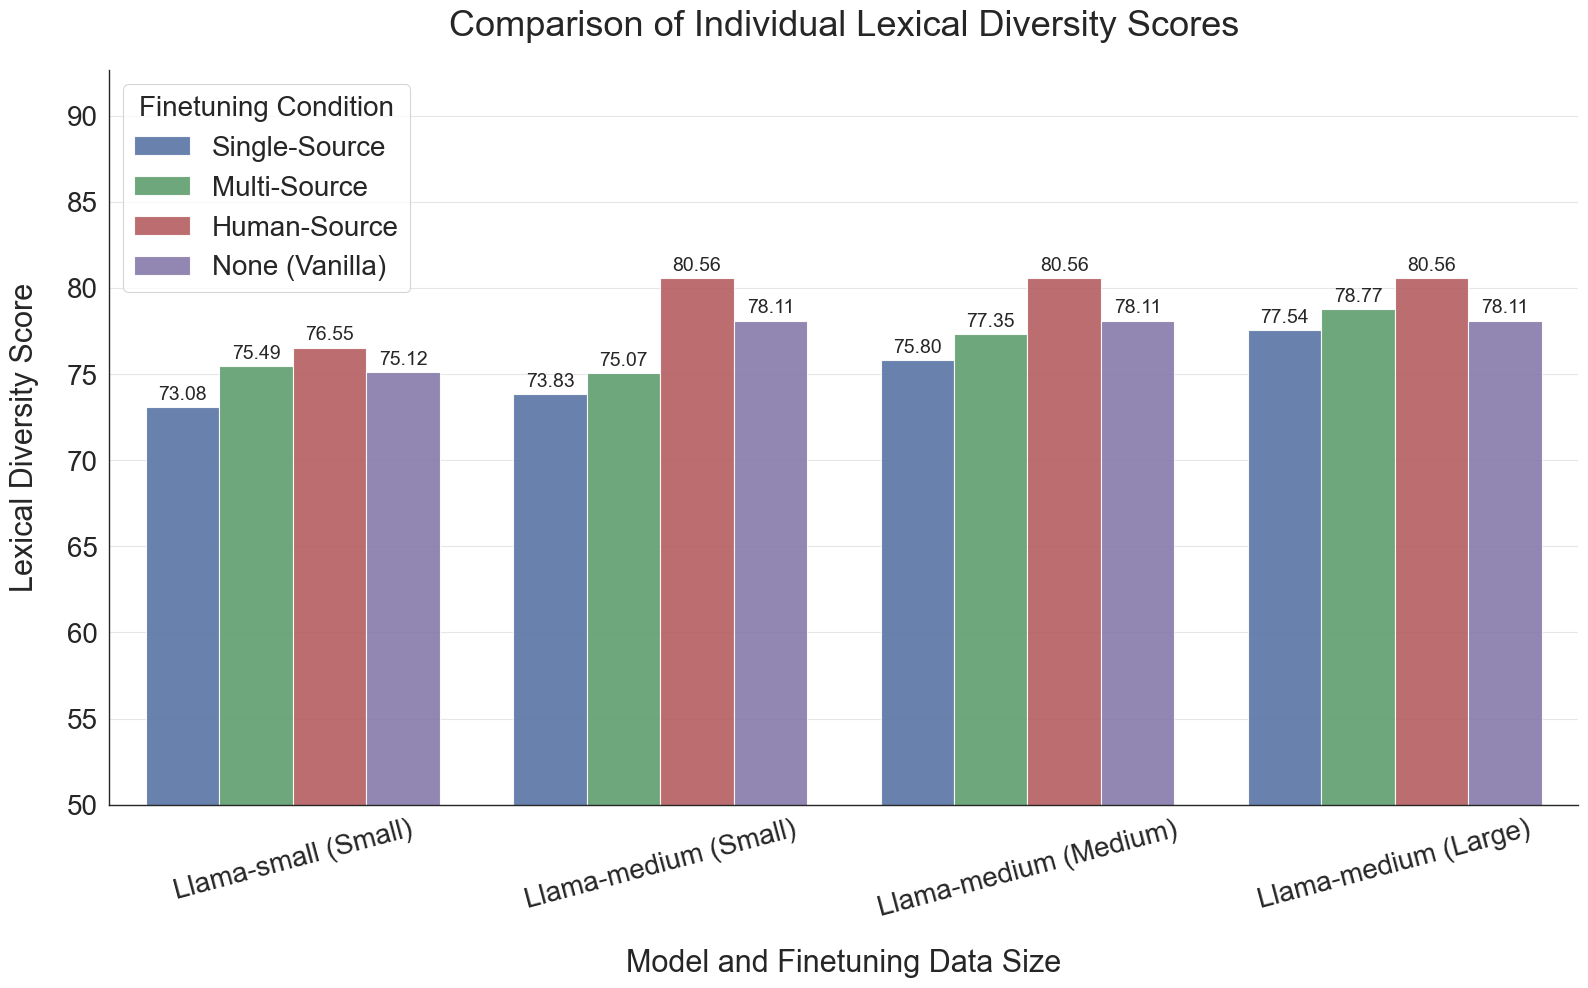

In [19]:
df = pd.DataFrame(data)
df['Finetuning Data Size'] = pd.Categorical(df['Finetuning Data Size'], categories=['Small', 'Medium', 'Large'], ordered=True)
df['Finetuning Condition'] = pd.Categorical(df['Finetuning Condition'], categories=['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'], ordered=True)

# --- 2. Prepare Data for Paired Bar Plot ---
# Filter for 'Individual' scores and 'Single-Source'/'Multi-Source' conditions
df_paired = df[
    (df['Score Type'] == 'Individual') & 
    (df['Finetuning Condition'].isin(['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)']))
].copy()

# Create a combined category for the x-axis
df_paired['Model-Size Category'] = df_paired['Model'] + " (" + df_paired['Finetuning Data Size'].astype(str) + ")"
# Define a specific order for the new category
category_order = [
    'Llama-small (Small)', 
    'Llama-medium (Small)', 
    'Llama-medium (Medium)', 
    'Llama-medium (Large)'
]
df_paired['Model-Size Category'] = pd.Categorical(df_paired['Model-Size Category'], categories=category_order, ordered=True)


# --- 3. Plotting the Paired Bar Chart ---
# Define a custom color palette for the conditions
bar_palette = {
    "Single-Source": "#4C72B0",  # blue
    "Multi-Source": "#55A868",   # green
    "Human-Source":  "#C44E52",  # red
    "None (Vanilla)": "#8172B2",  # purple
}

plt.figure(figsize=(16, 10))
ax_bar = sns.barplot(
    data=df_paired,
    x='Model-Size Category',
    y='Score',
    hue='Finetuning Condition',
    palette=bar_palette,
    alpha=0.9
)

# Add value labels on top of each bar
for p in ax_bar.patches:
    if p.get_height() > 0:
        ax_bar.annotate(format(p.get_height(), '.2f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 9), 
                       textcoords='offset points',
                       fontsize=14)

ax_bar.set_title('Comparison of Individual Lexical Diversity Scores', fontsize=26, pad=25)
ax_bar.set_xlabel('Model and Finetuning Data Size', fontsize=22, labelpad=20)
ax_bar.set_ylabel('Lexical Diversity Score', fontsize=22, labelpad=20)
ax_bar.tick_params(axis='x', labelsize=20, rotation=15)
ax_bar.tick_params(axis='y', labelsize=20)
ax_bar.set_ylim(50, df_paired['Score'].max() * 1.15)

# Adjust legend
legend = plt.legend(title='Finetuning Condition', loc='upper left', fontsize=20)
plt.setp(legend.get_title(), fontsize=20)

plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/paired_bar_lex_div_individual.png', dpi=300, bbox_inches='tight')
plt.show()